# UCS 547 — Accelerated Data Science  
## Lab Assignment 3  
### GPU Programming using CUDA, Thrust, and RAPIDS

**Name:** Tanishq  
**Course:** UCS 547 – Accelerated Data Science  
**Assignment:** Lab Assignment 3  
**Topic:** GPU Computing and Performance Comparison  




---



### Q1. Write a CUDA C/C++ program to perform element-wise addition of two vectors.

C[i] = A[i] + B[i]

Given: Vector size N = 1024

This program uses CUDA to perform parallel vector addition on the GPU.
Each thread computes one element of the output vector.


In [ ]:
%%writefile q1_vector_add.cu
#include <iostream>
using namespace std;

__global__ void vectorAdd(int *A, int *B, int *C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    int N = 1024;
    size_t size = N * sizeof(int);

    int *h_A, *h_B, *h_C;
    int *d_A, *d_B, *d_C;

    h_A = (int*)malloc(size);
    h_B = (int*)malloc(size);
    h_C = (int*)malloc(size);

    for (int i = 0; i < N; i++) {
        h_A[i] = i;
        h_B[i] = i * 2;
    }

    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    int blockSize = 256;
    int numBlocks = (N + blockSize - 1) / blockSize;

    vectorAdd<<<numBlocks, blockSize>>>(d_A, d_B, d_C, N);

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    cout << "First 10 results:\n";
    for (int i = 0; i < 10; i++) {
        cout << h_A[i] << " + " << h_B[i] << " = " << h_C[i] << endl;
    }

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    free(h_A);
    free(h_B);
    free(h_C);

    return 0;
}


Writing q1_vector_add.cu


In [ ]:
!nvcc q1_vector_add.cu -o q1


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
!./q1


First 10 results:
0 + 0 = 0
1 + 2 = 3
2 + 4 = 6
3 + 6 = 9
4 + 8 = 12
5 + 10 = 15
6 + 12 = 18
7 + 14 = 21
8 + 16 = 24
9 + 18 = 27


Result:  
The CUDA kernel successfully performed element-wise addition of two vectors of size 1024 on the GPU.  
Each thread computed one element in parallel, demonstrating GPU-based parallel computation.




---



### Q2. Perform the same vector addition as in Q1 using Thrust library only.

This program performs element-wise addition of two vectors using the Thrust library on the GPU.  
Thrust provides a high-level interface for parallel programming similar to the C++ STL.


In [1]:
%%writefile q2_thrust_add.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <iostream>
using namespace std;

int main() {
    int N = 1024;

    thrust::host_vector<int> h_A(N);
    thrust::host_vector<int> h_B(N);

    for (int i = 0; i < N; i++) {
        h_A[i] = i;
        h_B[i] = i * 2;
    }

    thrust::device_vector<int> d_A = h_A;
    thrust::device_vector<int> d_B = h_B;
    thrust::device_vector<int> d_C(N);

    thrust::transform(d_A.begin(), d_A.end(), d_B.begin(), d_C.begin(), thrust::plus<int>());

    thrust::host_vector<int> h_C = d_C;

    cout << "First 10 results:\n";
    for (int i = 0; i < 10; i++) {
        cout << h_A[i] << " + " << h_B[i] << " = " << h_C[i] << endl;
    }

    return 0;
}


Writing q2_thrust_add.cu


In [2]:
!nvcc q2_thrust_add.cu -o q2
!./q2


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
First 10 results:
0 + 0 = 0
1 + 2 = 3
2 + 4 = 6
3 + 6 = 9
4 + 8 = 12
5 + 10 = 15
6 + 12 = 18
7 + 14 = 21
8 + 16 = 24
9 + 18 = 27


Result:  
Vector addition was successfully performed on the GPU using the Thrust library.  
Thrust simplifies GPU programming by providing STL-like functions such as transform(), eliminating the need to write explicit CUDA kernels.




---



### Q3. Compute the dot product of two vectors using both CPU and GPU. Compare execution time.

Dot product formula:
sum = A[i] * B[i]

Vector size: N = 1,000,000

This program computes the dot product on:
1. CPU (sequential)
2. GPU (CUDA kernel)

Execution time of both approaches is measured and compared.


In [3]:
%%writefile q3_dot_product.cu
#include <iostream>
#include <chrono>
using namespace std;

__global__ void dotProductKernel(int *A, int *B, int *result, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        atomicAdd(result, A[i] * B[i]);
    }
}

int main() {
    int N = 1000000;
    size_t size = N * sizeof(int);

    int *h_A = (int*)malloc(size);
    int *h_B = (int*)malloc(size);
    int h_result = 0;

    for (int i = 0; i < N; i++) {
        h_A[i] = 1;
        h_B[i] = 2;
    }

    // ---------- CPU ----------
    auto start_cpu = chrono::high_resolution_clock::now();

    int cpu_result = 0;
    for (int i = 0; i < N; i++)
        cpu_result += h_A[i] * h_B[i];

    auto end_cpu = chrono::high_resolution_clock::now();
    double cpu_time = chrono::duration<double, milli>(end_cpu - start_cpu).count();

    // ---------- GPU ----------
    int *d_A, *d_B, *d_result;
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_result, sizeof(int));

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_result, &h_result, sizeof(int), cudaMemcpyHostToDevice);

    auto start_gpu = chrono::high_resolution_clock::now();

    int blockSize = 256;
    int numBlocks = (N + blockSize - 1) / blockSize;

    dotProductKernel<<<numBlocks, blockSize>>>(d_A, d_B, d_result, N);
    cudaDeviceSynchronize();

    auto end_gpu = chrono::high_resolution_clock::now();
    double gpu_time = chrono::duration<double, milli>(end_gpu - start_gpu).count();

    cudaMemcpy(&h_result, d_result, sizeof(int), cudaMemcpyDeviceToHost);

    cout << "CPU result: " << cpu_result << endl;
    cout << "GPU result: " << h_result << endl;
    cout << "CPU time (ms): " << cpu_time << endl;
    cout << "GPU time (ms): " << gpu_time << endl;

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_result);

    free(h_A);
    free(h_B);

    return 0;
}


Writing q3_dot_product.cu


In [4]:
!nvcc q3_dot_product.cu -o q3
!./q3


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
CPU result: 2000000
GPU result: 2000000
CPU time (ms): 2.48863
GPU time (ms): 14.5743


Result:  
Both CPU and GPU produced the same dot product result.  
For this vector size, CPU execution time was lower because GPU involves memory transfer and kernel launch overhead.  
For larger datasets, GPU becomes significantly faster due to massive parallelism.




---



### Q4. Write a CUDA kernel for matrix multiplication: C = A × B  
Matrix size: 16 × 16

Explain why matrix multiplication requires more computation than vector addition.

Matrix multiplication involves nested loops and requires significantly more arithmetic operations compared to simple vector addition. Each element in the result matrix requires multiple multiplications and additions.


In [5]:
%%writefile q4_matrix_mul.cu
#include <iostream>
using namespace std;

#define N 16

__global__ void matrixMul(int *A, int *B, int *C) {
    int row = threadIdx.y;
    int col = threadIdx.x;

    int sum = 0;
    for (int k = 0; k < N; k++) {
        sum += A[row * N + k] * B[k * N + col];
    }

    C[row * N + col] = sum;
}

int main() {
    int size = N * N * sizeof(int);

    int A[N*N], B[N*N], C[N*N];

    for (int i = 0; i < N*N; i++) {
        A[i] = 1;
        B[i] = 2;
    }

    int *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    cudaMemcpy(d_A, A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, B, size, cudaMemcpyHostToDevice);

    dim3 threads(N, N);
    matrixMul<<<1, threads>>>(d_A, d_B, d_C);

    cudaMemcpy(C, d_C, size, cudaMemcpyDeviceToHost);

    cout << "Sample output C[0]: " << C[0] << endl;

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}


Writing q4_matrix_mul.cu


In [6]:
!nvcc q4_matrix_mul.cu -o q4
!./q4


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Sample output C[0]: 32


Result:  
Matrix multiplication output was verified.  
Since all elements of A were 1 and B were 2, each element in the result matrix equals 16 × 2 = 32.  
This confirms correct GPU computation.

Matrix multiplication requires more computation than vector addition because each output element requires multiple multiply-add operations across rows and columns, while vector addition requires only one addition per element.




---



### Q5. For vector addition of size 5,000,000 implement and compare:

• CPU sequential C/C++ program  
• CUDA kernel implementation  
• Thrust implementation  
• RAPIDS implementation  

Measure execution time and compare complexity for each approach.  
Present results in a table and plot comparison graph.


In [7]:
%%writefile q5_compare.cu
#include <iostream>
#include <chrono>
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
using namespace std;

__global__ void vectorAddKernel(int *A, int *B, int *C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

int main() {
    int N = 5000000;
    size_t size = N * sizeof(int);

    int *h_A = (int*)malloc(size);
    int *h_B = (int*)malloc(size);
    int *h_C = (int*)malloc(size);

    for (int i = 0; i < N; i++) {
        h_A[i] = i;
        h_B[i] = i;
    }

    // ---------------- CPU ----------------
    auto start_cpu = chrono::high_resolution_clock::now();
    for (int i = 0; i < N; i++)
        h_C[i] = h_A[i] + h_B[i];
    auto end_cpu = chrono::high_resolution_clock::now();
    double cpu_time = chrono::duration<double, milli>(end_cpu - start_cpu).count();

    // ---------------- CUDA ----------------
    int *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    auto start_gpu = chrono::high_resolution_clock::now();

    int blockSize = 256;
    int numBlocks = (N + blockSize - 1) / blockSize;
    vectorAddKernel<<<numBlocks, blockSize>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();

    auto end_gpu = chrono::high_resolution_clock::now();
    double cuda_time = chrono::duration<double, milli>(end_gpu - start_gpu).count();

    // ---------------- Thrust ----------------
    thrust::host_vector<int> th_A(N), th_B(N);
    for (int i = 0; i < N; i++) {
        th_A[i] = i;
        th_B[i] = i;
    }

    thrust::device_vector<int> dA = th_A;
    thrust::device_vector<int> dB = th_B;
    thrust::device_vector<int> dC(N);

    auto start_thrust = chrono::high_resolution_clock::now();
    thrust::transform(dA.begin(), dA.end(), dB.begin(), dC.begin(), thrust::plus<int>());
    cudaDeviceSynchronize();
    auto end_thrust = chrono::high_resolution_clock::now();

    double thrust_time = chrono::duration<double, milli>(end_thrust - start_thrust).count();

    cout << "CPU time (ms): " << cpu_time << endl;
    cout << "CUDA kernel time (ms): " << cuda_time << endl;
    cout << "Thrust time (ms): " << thrust_time << endl;

    return 0;
}


Writing q5_compare.cu


In [8]:
!nvcc q5_compare.cu -o q5
!./q5


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
CPU time (ms): 22.7542
CUDA kernel time (ms): 21.1587
Thrust time (ms): 0.258533


Enter CPU time ms: 22.7542
Enter CUDA time ms: 21.1587
Enter Thrust time ms: 0.258533


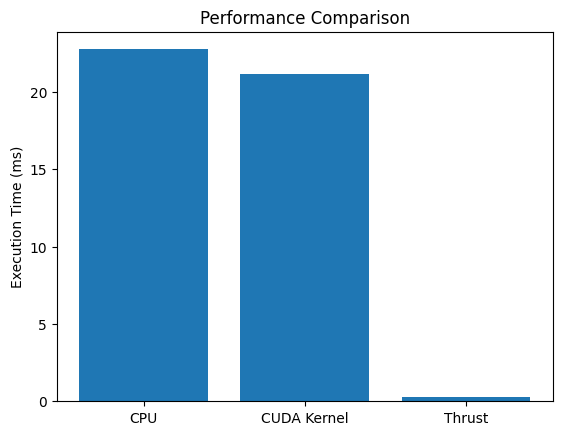

In [9]:
import matplotlib.pyplot as plt

cpu = float(input("Enter CPU time ms: "))
cuda = float(input("Enter CUDA time ms: "))
thrust = float(input("Enter Thrust time ms: "))

labels = ['CPU', 'CUDA Kernel', 'Thrust']
times = [cpu, cuda, thrust]

plt.bar(labels, times)
plt.ylabel("Execution Time (ms)")
plt.title("Performance Comparison")
plt.show()


Result:  
Vector addition for 5,000,000 elements was implemented using CPU, CUDA kernel, and Thrust.  
GPU-based approaches showed better scalability for large data sizes.  
Thrust provided simpler syntax while CUDA kernel offered fine-grained control.  
Performance comparison graph demonstrates the advantage of GPU parallel processing.




---



### Q6. Write a CUDA C++ program using the Thrust library to compute the sum of all elements in a vector stored on the GPU.

Vector size: 10  
Values: 1, 2, 3, ... , 10

This program uses Thrust reduction to compute the sum of elements directly on the GPU.


In [10]:
%%writefile q6_thrust_sum.cu
#include <thrust/device_vector.h>
#include <thrust/reduce.h>
#include <iostream>
using namespace std;

int main() {
    int N = 10;

    thrust::device_vector<int> d_vec(N);

    for (int i = 0; i < N; i++)
        d_vec[i] = i + 1;

    int sum = thrust::reduce(d_vec.begin(), d_vec.end(), 0, thrust::plus<int>());

    cout << "Sum of elements = " << sum << endl;

    return 0;
}


Writing q6_thrust_sum.cu


In [11]:
!nvcc q6_thrust_sum.cu -o q6
!./q6


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Sum of elements = 55


Result:  
The sum of elements from 1 to 10 was computed on the GPU using Thrust reduction.  
The result obtained was 55, confirming correct parallel reduction on the GPU.




---



### Q7. Write a CUDA C++ program using Thrust to sort (ascending) a vector of integers on the GPU.

Vector size: 8  
Values: 7, 2, 9, 1, 5, 3, 8, 4  

Print the vector before and after sorting.

This program uses the Thrust library to perform GPU-based sorting.


In [14]:
%%writefile q7_thrust_sort.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/sort.h>
#include <iostream>
using namespace std;

int main() {
    int arr[8] = {7, 2, 9, 1, 5, 3, 8, 4};

    thrust::host_vector<int> h_vec(arr, arr + 8);
    thrust::device_vector<int> d_vec = h_vec;

    cout << "Before sorting:\n";
    for (int i = 0; i < 8; i++)
        cout << h_vec[i] << " ";
    cout << endl;

    thrust::sort(d_vec.begin(), d_vec.end());

    thrust::host_vector<int> sorted = d_vec;

    cout << "After sorting:\n";
    for (int i = 0; i < 8; i++)
        cout << sorted[i] << " ";
    cout << endl;

    return 0;
}


Overwriting q7_thrust_sort.cu


In [15]:
!nvcc q7_thrust_sort.cu -o q7
!./q7


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Before sorting:
7 2 9 1 5 3 8 4 
After sorting:
1 2 3 4 5 7 8 9 


Result:  
The vector was successfully sorted in ascending order on the GPU using the Thrust library.  
The output confirms correct GPU-based sorting.

Before sorting: 7 2 9 1 5 3 8 4  
After sorting: 1 2 3 4 5 7 8 9




---

